In [3]:
#Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

I0000 00:00:1778007529.291516  163137 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778007529.341075  163137 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778007530.428718  163137 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [4]:
#Step 2: Load Dataset
# Load dataset
df = pd.read_csv("1_boston_housing.csv")

# Remove quotes from column names (important for your dataset)
df.columns = df.columns.str.replace('"', '')

# Display first 5 rows
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [5]:
#Step 3: Split Features and Target
X = df.drop("MEDV", axis=1)   # Features
y = df["MEDV"]                # Target

print(X.shape, y.shape)

(506, 13) (506,)


In [6]:
#Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
#Step 5: Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

array([[12. ],
       [19.9],
       [19.4],
       [13.4],
       [18.2],
       [24.6],
       [21.1],
       [24.7],
       [ 8.7],
       [27.5],
       [20.7],
       [36.2],
       [31.6],
       [11.7],
       [39.8],
       [13.9],
       [21.8],
       [23.7],
       [17.6],
       [24.4],
       [ 8.8],
       [19.2],
       [25.3],
       [20.4],
       [23.1],
       [37.9],
       [15.6],
       [45.4],
       [15.7],
       [22.6],
       [14.5],
       [18.7],
       [17.8],
       [16.1],
       [20.6],
       [31.6],
       [29.1],
       [15.6],
       [17.5],
       [22.5],
       [19.4],
       [19.3],
       [ 8.5],
       [20.6],
       [17. ],
       [17.1],
       [14.5],
       [50. ],
       [14.3],
       [12.6],
       [28.7],
       [21.2],
       [19.3],
       [23.1],
       [19.1],
       [25. ],
       [33.4],
       [ 5. ],
       [29.6],
       [18.7],
       [21.7],
       [23.1],
       [22.8],
       [21. ],
       [48.8],
       [14.6],
       [16

In [14]:
#Step 6: Build Deep Neural Network
model = Sequential()

# Single neuron → behaves like linear regression
model.add(Dense(1, input_shape=(X_train.shape[1],), activation='linear'))
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

/home/vivek/jupyter_env/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 1)              │            14 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,255 (8.81 KB)

 Trainable params: 2,255 (8.81 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
#Step 7: Train Model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 612.7900 - mae: 22.8282 - val_loss: 543.8262 - val_mae: 21.7629
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 593.2690 - mae: 22.3909 - val_loss: 521.2847 - val_mae: 21.2379
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 564.1517 - mae: 21.7295 - val_loss: 482.4672 - val_mae: 20.2911
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 510.6880 - mae: 20.4528 - val_loss: 416.2445 - val_mae: 18.5553
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 418.5818 - mae: 18.0628 - val_loss: 310.6241 - val_mae: 15.4008
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 288.9172 - mae: 14.1764 - val_loss: 185.1676 - val_mae: 10.9680
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 166.0292 - mae: 9.8263 - val_loss: 105.6879 - val_mae: 7.8030
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 113.5872 - mae: 8.0335 - val_loss: 85.3051 - val_mae: 6.8581
Epoch 9/100
21/21 ━━━

In [16]:
#Step 8: Evaluate Model
loss, mae = model.evaluate(X_test, y_test)

print("Test Loss (MSE):", loss)
print("Test MAE:", mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 24.9123 - mae: 2.8857 
Test Loss (MSE): 24.912328720092773
Test MAE: 2.885697364807129


In [17]:
#Step 9: Predictions
y_pred = model.predict(X_test)

# Compare actual vs predicted
for i in range(5):
    print(f"Actual: {y_test.iloc[i]:.2f} | Predicted: {y_pred[i][0]:.2f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Actual: 23.60 | Predicted: 24.63
Actual: 32.40 | Predicted: 34.06
Actual: 13.60 | Predicted: 14.81
Actual: 22.80 | Predicted: 22.44
Actual: 16.10 | Predicted: 14.56


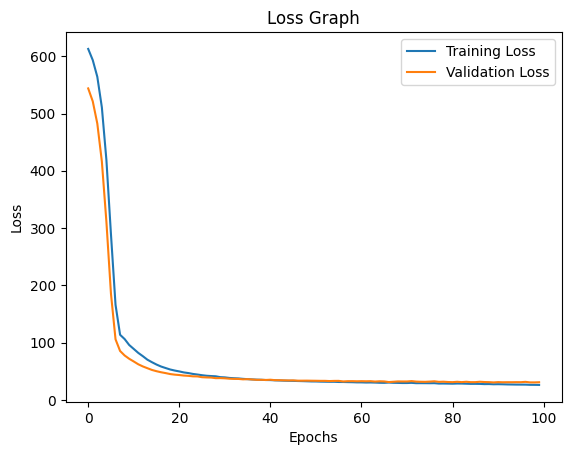

In [18]:
#Step 10: Plot Training Graphs
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()